In [ ]:
#Atul Singh UIN:-221A016

In [ ]:
!pip install gymnasium

In [ ]:
import os
import gymnasium as gym
import numpy as np

array([[[110, 109, 106],
        [110, 109, 106],
        [124, 122, 122],
        ...,
        [108, 111, 109],
        [108, 111, 109],
        [118, 119, 119]],

       [[110, 109, 106],
        [110, 109, 106],
        [124, 122, 122],
        ...,
        [108, 111, 109],
        [108, 111, 109],
        [118, 119, 119]],

       [[114, 116, 115],
        [114, 116, 115],
        [126, 127, 126],
        ...,
        [112, 113, 111],
        [112, 113, 111],
        [118, 117, 115]],

       ...,

       [[116, 115, 116],
        [116, 115, 116],
        [106, 107, 108],
        ...,
        [113, 115, 114],
        [113, 115, 114],
        [117, 114, 117]],

       [[116, 115, 116],
        [116, 115, 116],
        [106, 107, 108],
        ...,
        [113, 115, 114],
        [113, 115, 114],
        [117, 114, 117]],

       [[115, 112, 112],
        [115, 112, 112],
        [119, 119, 117],
        ...,
        [123, 119, 118],
        [123, 119, 118],
        [114, 114, 117]]], dtype=uint8)
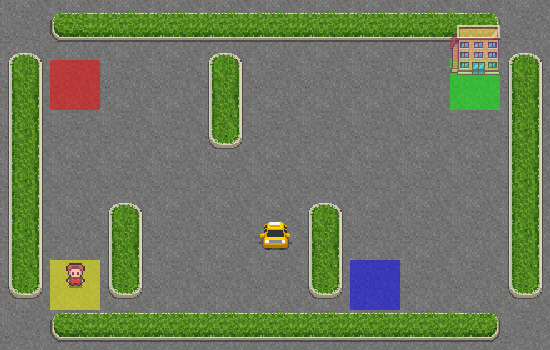

In [ ]:
env = gym.make("Taxi-v3", render_mode="rgb_array")
env.reset()

frame = env.render()
frame


In [ ]:
n_states=env.observation_space.n
n_actions=env.action_space.n

In [ ]:
n_actions

np.int64(6)

In [ ]:
n_states

np.int64(500)

In [ ]:
env.step(0)

(449,
 -1,
 False,
 False,
 {'prob': 1.0, 'action_mask': array([0, 1, 0, 1, 0, 0], dtype=int8)})

In [ ]:
env.step(1)

(349,
 -1,
 False,
 False,
 {'prob': 1.0, 'action_mask': array([1, 1, 0, 1, 0, 0], dtype=int8)})

In [ ]:
state=env.reset()
counter=0
g=0
reward=None

In [ ]:
counter = 0
g = 0
reward = 0

state, info = env.reset()

while reward != 20:
    state, reward, terminated, truncated, info = env.step(env.action_space.sample())
    counter += 1
    g += reward

    if terminated or truncated:
        state, info = env.reset()

In [ ]:
print("Solved in {} Steps with a total reward of {}".format(counter,g))

Solved in 3488 Steps with a total reward of -12917


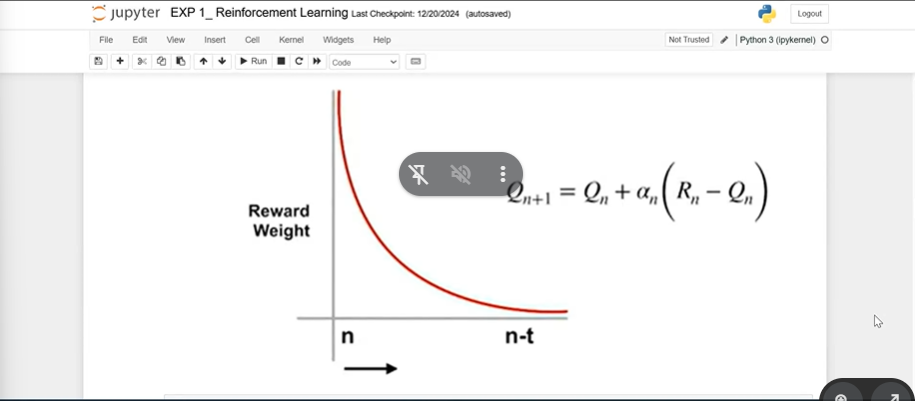

In [ ]:
Q=np.zeros([n_states,n_actions])
Q.shape

(500, 6)

In [ ]:
episodes=1000
rewardTracker=[]
G=0
alpha=0.9

for episode in range(1,episodes+1):
  done=False
  G,reward=0,0
  state, info = env.reset() # Correctly unpack state and info
  finalState = state
  # print("Initial state {}".format(state))
  while done !=True:
    action=np.argmax(Q[state])
    state2,reward,terminated,truncated,info=env.step(action)     # Correctly unpack all return values
    rewardTracker.append(reward)
    done = terminated or truncated # Update done based on new Gymnasium API
    Q[state,action]=Q[state,action]+alpha*(reward+np.max(Q[state2])-Q[state,action])
    G+= reward
    state=state2
  if episode % 100 == 0:
    print('Episode {} Total Reward: {}'.format(episode,G))
print(f"MAX REWARD: {np.max(rewardTracker)}")
print(f"MIN REWARD: {np.min(rewardTracker)}")
print(f"AVG REWARD: {np.mean(rewardTracker)}")
G


Episode 100 Total Reward: 5
Episode 200 Total Reward: 6
Episode 300 Total Reward: 9
Episode 400 Total Reward: 7
Episode 500 Total Reward: 7
Episode 600 Total Reward: 3
Episode 700 Total Reward: 8
Episode 800 Total Reward: 5
Episode 900 Total Reward: 6
Episode 1000 Total Reward: 8
MAX REWARD: 20
MIN REWARD: -1
AVG REWARD: 0.589825119236884


8